In [1]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
# fetch dataset 
nursery = fetch_ucirepo(id=76) 

In [2]:
## Imporat relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import roc_curve, auc
from sklearn import tree
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# Get full dataset (features + target together)
df = nursery.data.original

print(df.shape)
df

(12960, 9)


,parents,has_nurs,form,children,housing,finance,social,health,class
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority
...,...,...,...,...,...,...,...,...,...
12955,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,priority,spec_prior
12956,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,not_recom,not_recom
12957,great_pret,very_crit,foster,more,critical,inconv,problematic,recommended,spec_prior
12958,great_pret,very_crit,foster,more,critical,inconv,problematic,priority,spec_prior


### EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   parents   12960 non-null  object
 1   has_nurs  12960 non-null  object
 2   form      12960 non-null  object
 3   children  12960 non-null  object
 4   housing   12960 non-null  object
 5   finance   12960 non-null  object
 6   social    12960 non-null  object
 7   health    12960 non-null  object
 8   class     12960 non-null  object
dtypes: object(9)
memory usage: 911.4+ KB


In [5]:
df.shape

(12960, 9)

In [6]:
### Check missing values
df.isnull().sum()

parents     0
has_nurs    0
form        0
children    0
housing     0
finance     0
social      0
health      0
class       0
dtype: int64

In [7]:
## Unique values per column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

parents: 3 unique values
has_nurs: 5 unique values
form: 4 unique values
children: 4 unique values
housing: 3 unique values
finance: 2 unique values
social: 3 unique values
health: 3 unique values
class: 5 unique values


In [8]:
df['class'].value_counts(normalize=True)

class
not_recom     0.333333
priority      0.329167
spec_prior    0.312037
very_recom    0.025309
recommend     0.000154
Name: proportion, dtype: float64

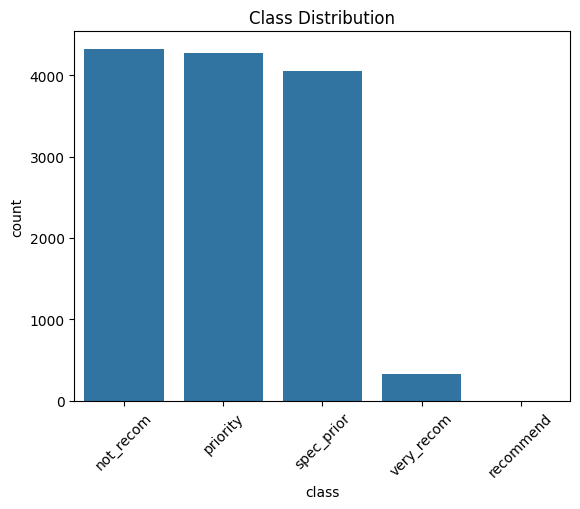

In [9]:
sns.countplot(data=df, x='class', order=df['class'].value_counts().index)
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.show()

In [10]:
df['class'] = df['class'].replace({'recommend': 'very_recom'}) # Merge recommend and very_recom

In [11]:
df['class'].value_counts(normalize=True)

class
not_recom     0.333333
priority      0.329167
spec_prior    0.312037
very_recom    0.025463
Name: proportion, dtype: float64

In [12]:
for col in df.columns:
    print(f"Column: {col}")
    print(f"Unique values ({df[col].nunique()}): {df[col].unique()}")
    print(df[col].value_counts())  # proportion of each category
    print("-"*40)


Column: parents
Unique values (3): ['usual' 'pretentious' 'great_pret']
parents
usual          4320
pretentious    4320
great_pret     4320
Name: count, dtype: int64
----------------------------------------
Column: has_nurs
Unique values (5): ['proper' 'less_proper' 'improper' 'critical' 'very_crit']
has_nurs
proper         2592
less_proper    2592
improper       2592
critical       2592
very_crit      2592
Name: count, dtype: int64
----------------------------------------
Column: form
Unique values (4): ['complete' 'completed' 'incomplete' 'foster']
form
complete      3240
completed     3240
incomplete    3240
foster        3240
Name: count, dtype: int64
----------------------------------------
Column: children
Unique values (4): ['1' '2' '3' 'more']
children
1       3240
2       3240
3       3240
more    3240
Name: count, dtype: int64
----------------------------------------
Column: housing
Unique values (3): ['convenient' 'less_conv' 'critical']
housing
convenient    4320
less_conv 

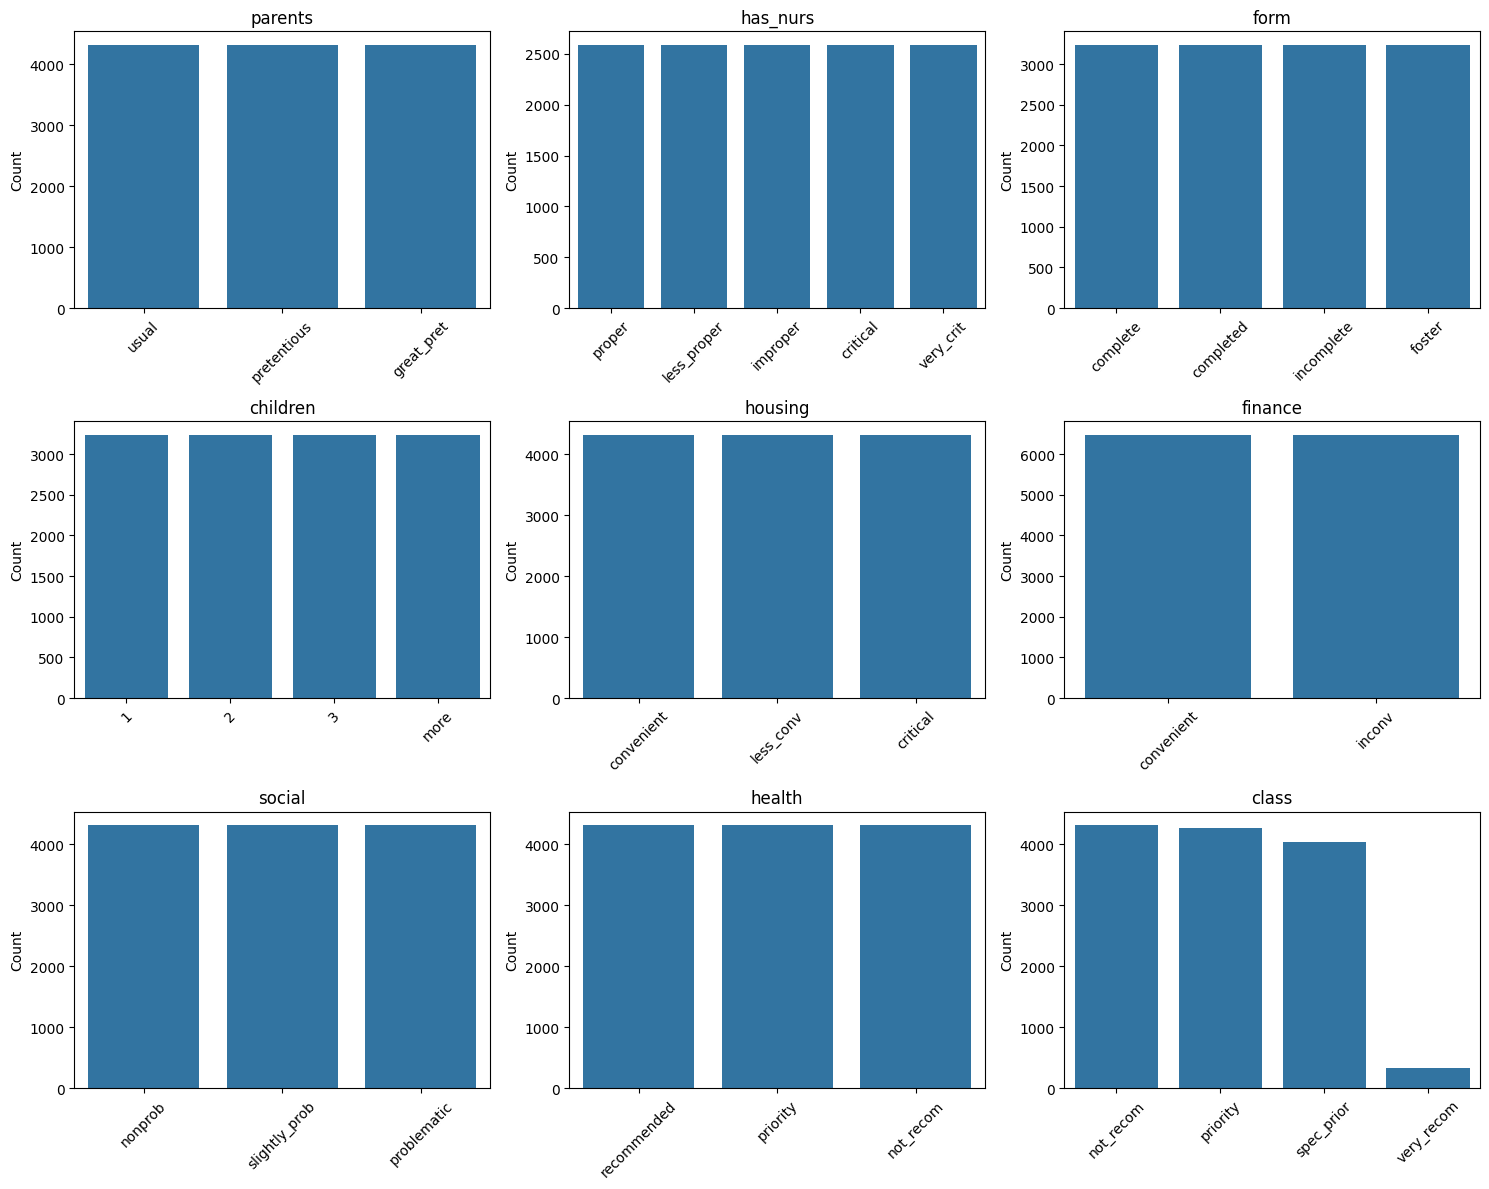

In [13]:
cols = df.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))

for i, col in enumerate(cols):
    ax = axes[i // n_cols, i % n_cols]
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

# Hide empty subplots if any
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()


In [14]:
# Train /test/validation split
from sklearn.model_selection import train_test_split
df_full_train , df_test = train_test_split(df, test_size = 0.2, random_state = 11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state =11)

In [15]:
df_train = df_train.reset_index(drop =True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [16]:
len(df_train), len(df_val), len(df_test)

(7776, 2592, 2592)

In [17]:
# Separate features 
df_train_f = df_train.drop('class', axis=1)
df_val_f = df_val.drop('class', axis=1)
df_test_f = df_test.drop('class', axis=1)

In [18]:
## Target Features
y_train = df_train['class']
y_val = df_val['class']
y_test = df_test['class']

In [19]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

print(le.classes_)   # shows mapping like ['not_recom', 'priority', 'spec_prior', 'very_recom']

['not_recom' 'priority' 'spec_prior' 'very_recom']


In [20]:
from sklearn.preprocessing import label_binarize

# Assuming LabelEncoder classes: 0,1,2,3
classes = le.classes_  # ['not_recom', 'priority', 'spec_prior', 'very_recom']
y_val_bin = label_binarize(y_val, classes=[0,1,2,3])

### XGboost 

In [21]:
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(df_train_f.to_dict(orient='records'))
X_val = dv.transform(df_val_f.to_dict(orient='records'))
X_test = dv.transform(df_test_f.to_dict(orient='records'))

In [22]:
features = dv.get_feature_names_out().tolist() # call the method
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [23]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [24]:
val_dicts = df_val.to_dict(orient = 'records')
X_val = dv.transform(val_dicts)

In [25]:
%%capture output
xgb_params = {
    'eta': 0.3,                  # learning rate
    'max_depth': 6,              # max tree depth
    'min_child_weight': 1,       # min sum of instance weight in a leaf
    'objective': 'multi:softprob', # multi-class probability outputs
    'num_class': len(classes),    # total number of classes
    'nthread': 8,                # number of threads
    'seed': 1,                   # reproducibility
    'verbosity': 1               # 0=silent, 1=warning, 2=info
}
xgboost_model = xgb.train(xgb_params, dtrain, 
                  evals = watchlist,
                  verbose_eval= 5,
                  num_boost_round=100)


In [26]:
s = output.stdout
print(s)

[0]	train-mlogloss:0.92300	val-mlogloss:0.92008
[5]	train-mlogloss:0.31452	val-mlogloss:0.31370
[10]	train-mlogloss:0.16574	val-mlogloss:0.16936
[15]	train-mlogloss:0.10191	val-mlogloss:0.10809
[20]	train-mlogloss:0.06907	val-mlogloss:0.07537
[25]	train-mlogloss:0.04659	val-mlogloss:0.05255
[30]	train-mlogloss:0.03204	val-mlogloss:0.03739
[35]	train-mlogloss:0.02341	val-mlogloss:0.02849
[40]	train-mlogloss:0.01712	val-mlogloss:0.02167
[45]	train-mlogloss:0.01300	val-mlogloss:0.01693
[50]	train-mlogloss:0.01030	val-mlogloss:0.01365
[55]	train-mlogloss:0.00831	val-mlogloss:0.01110
[60]	train-mlogloss:0.00688	val-mlogloss:0.00933
[65]	train-mlogloss:0.00587	val-mlogloss:0.00804
[70]	train-mlogloss:0.00506	val-mlogloss:0.00704
[75]	train-mlogloss:0.00444	val-mlogloss:0.00624
[80]	train-mlogloss:0.00397	val-mlogloss:0.00566
[85]	train-mlogloss:0.00364	val-mlogloss:0.00525
[90]	train-mlogloss:0.00329	val-mlogloss:0.00476
[95]	train-mlogloss:0.00307	val-mlogloss:0.00451
[99]	train-mlogloss:0.

### Feature Importance

### Parameter Tuning

### Cross Validation

In [29]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

In [31]:
# Use accuracy as metric (or f1_macro for multiclass balance)
scores = cross_val_score(xgboost_model, X_train, y_train, cv=cv, scoring='f1_macro')

print("F1 Macro scores for each fold:", scores)
print("Mean F1 Macro:", np.mean(scores))
print("Std deviation:", np.std(scores))

InvalidParameterError: The 'estimator' parameter of cross_val_score must be an object implementing 'fit'. Got <xgboost.core.Booster object at 0x11bcf1cd0> instead.